# Solar Panel Daily Output — Mini Project

A small project estimating how much energy a rooftop solar panel produces
per day, based on its size and the local sunlight it gets, then using
linear regression to predict output from those two numbers.

Note: the dataset here is synthetically generated

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

## 2. A tiny class for one panel

`SolarPanel` stores a panel's size and sun hours, and has one method that
calculates its daily output. 

In [2]:
class SolarPanel:
    def __init__(self, size_kw, sun_hours):
        self.size_kw = size_kw
        self.sun_hours = sun_hours

    def daily_output_kwh(self):
        return self.size_kw * self.sun_hours * 0.8  # 0.8 = efficiency factor

panel = SolarPanel(size_kw=3, sun_hours=5)
print(f"Daily output: {panel.daily_output_kwh():.1f} kWh")

Daily output: 12.0 kWh


## 3. Building a small dataset

20 panels with randomised size and sun-hours values, with daily output
calculated for each using the same formula as above.

In [4]:
np.random.seed(0)
n = 20

df = pd.DataFrame({
    "size_kw": np.round(np.random.uniform(2, 10, n), 1),
    "sun_hours": np.round(np.random.uniform(4, 6, n), 1),
})

df["daily_output_kwh"] = df["size_kw"] * df["sun_hours"] * 0.8
df.head()

,size_kw,sun_hours,daily_output_kwh
0,6.4,6.0,30.720
1,7.7,5.6,34.496
2,6.8,4.9,26.656
3,6.4,5.6,28.672
4,5.4,4.2,18.144


## 4.  A look at the data

In [5]:
df.describe()

,size_kw,sun_hours,daily_output_kwh
count,20.000000,20.000000,20.000000
mean,6.655000,5.125000,27.647200
std,2.254697,0.566499,10.482355
min,2.200000,4.000000,8.320000
25%,5.475000,4.875000,19.418000
50%,6.650000,5.200000,29.276000
75%,8.400000,5.525000,36.732000
max,9.700000,6.000000,42.952000


## 5. A simple chart

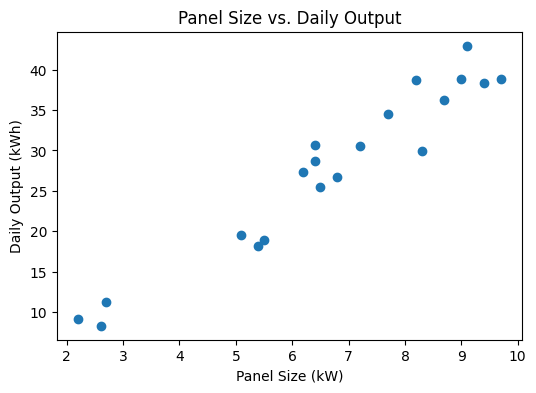

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(df["size_kw"], df["daily_output_kwh"])
plt.xlabel("Panel Size (kW)")
plt.ylabel("Daily Output (kWh)")
plt.title("Panel Size vs. Daily Output")
plt.show()

## 6. Predicting output with Linear Regression

Using `size_kw` and `sun_hours` to predict `daily_output_kwh`. The data
is split into training and test sets so the model is checked on panels
it hasn't seen.

- **R² score**: how much of the variation in output the model explains
  (closer to 1.0 is better).
- **Mean Absolute Error**: on average, how far off the predictions are,
  in kWh.

In [7]:
X = df[["size_kw", "sun_hours"]]
y = df["daily_output_kwh"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f"R2 score: {r2_score(y_test, predictions):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f} kWh")

R2 score: 0.91
Mean Absolute Error: 0.95 kWh


## 7. Conclusion

The model predicts daily output well from size and sun hours. Since
the data is synthetic and based on a simple formula, this mainly shows
the workflow rather than a real world discovery. 